In [4]:
#============================================
# 1. importaciones y configuraciones
#============================================

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuración de estilo para gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
np.random.seed(42)

# Para que pandas muestre todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("✅ Librerias cargadas correctamente")

✅ Librerias cargadas correctamente


In [ ]:
#===================================
# 2. Carga de datos
#===================================

df = pd.read_csv("D:\\05 - Modelo Scoring Crediticion\\Codigo\\scoring_crediticio\\data\\raw\\scoring_crediticio.csv")

print("=" * 60)
print("✅ INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nNombres de columnas:")
for col in df.columns:
    print(f"- {col}")

In [ ]:
#============================================
# 3. Primer vistazo a los datos
#============================================

print("🔍 Primeras 5 lineas:")
display(df.head())

print("\n🔍 Ultimas 5 lineas:")
display(df.tail())

print("\n🔍 Tipos de datos:")
display(df.dtypes)

print("\n🔍 Valores nulos por columnas:")
display(df.isnull().sum())

In [ ]:
#==============================================
# 4. Estadistica Descriptiva
#==============================================

print("📊 Estadistica de variables numéricas:")
display(df.describe().T) # .T = transpuesta para ver mejor

print("\n📊 Estadistica de variables categóricas:")
display(df.describe(include='object').T) # .T = transpuesta para ver mejor

#"""
#Que debemos observar en esta sección:
#- Los minimos y maximos son razonables?
#- Hay valores con media muy diferente a la mediana? (posibles outliers)
#- Cuantas categorias unicas hay en las variables de texto?
#- Hay valores nulos en las variables categóricas?
#"""

In [ ]:
#===============================================
# 5. Análisis del TARGET (default)
#===============================================

# Distribución del TARGET (default)
target_counts = df['default'].value_counts()
target_pct = df['default'].value_counts(normalize=True) * 100

print("=" * 60)
print("🎯 DISTRIBUCIÓN DEL TARGET (default)")
print("=" * 60)
print(f"Buenos pagadores (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Malos pagadores (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nRatio de desbalanceo: 1 malo por cada {target_counts[0] / target_counts[1]:.1f} buenos")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
sns.countplot(data=df, x='default', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución del TARGET (default)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default (0 = Buenos, 1 = Malos)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(target_counts.values, labels=['Buenos', 'Malos'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('proporcion del target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

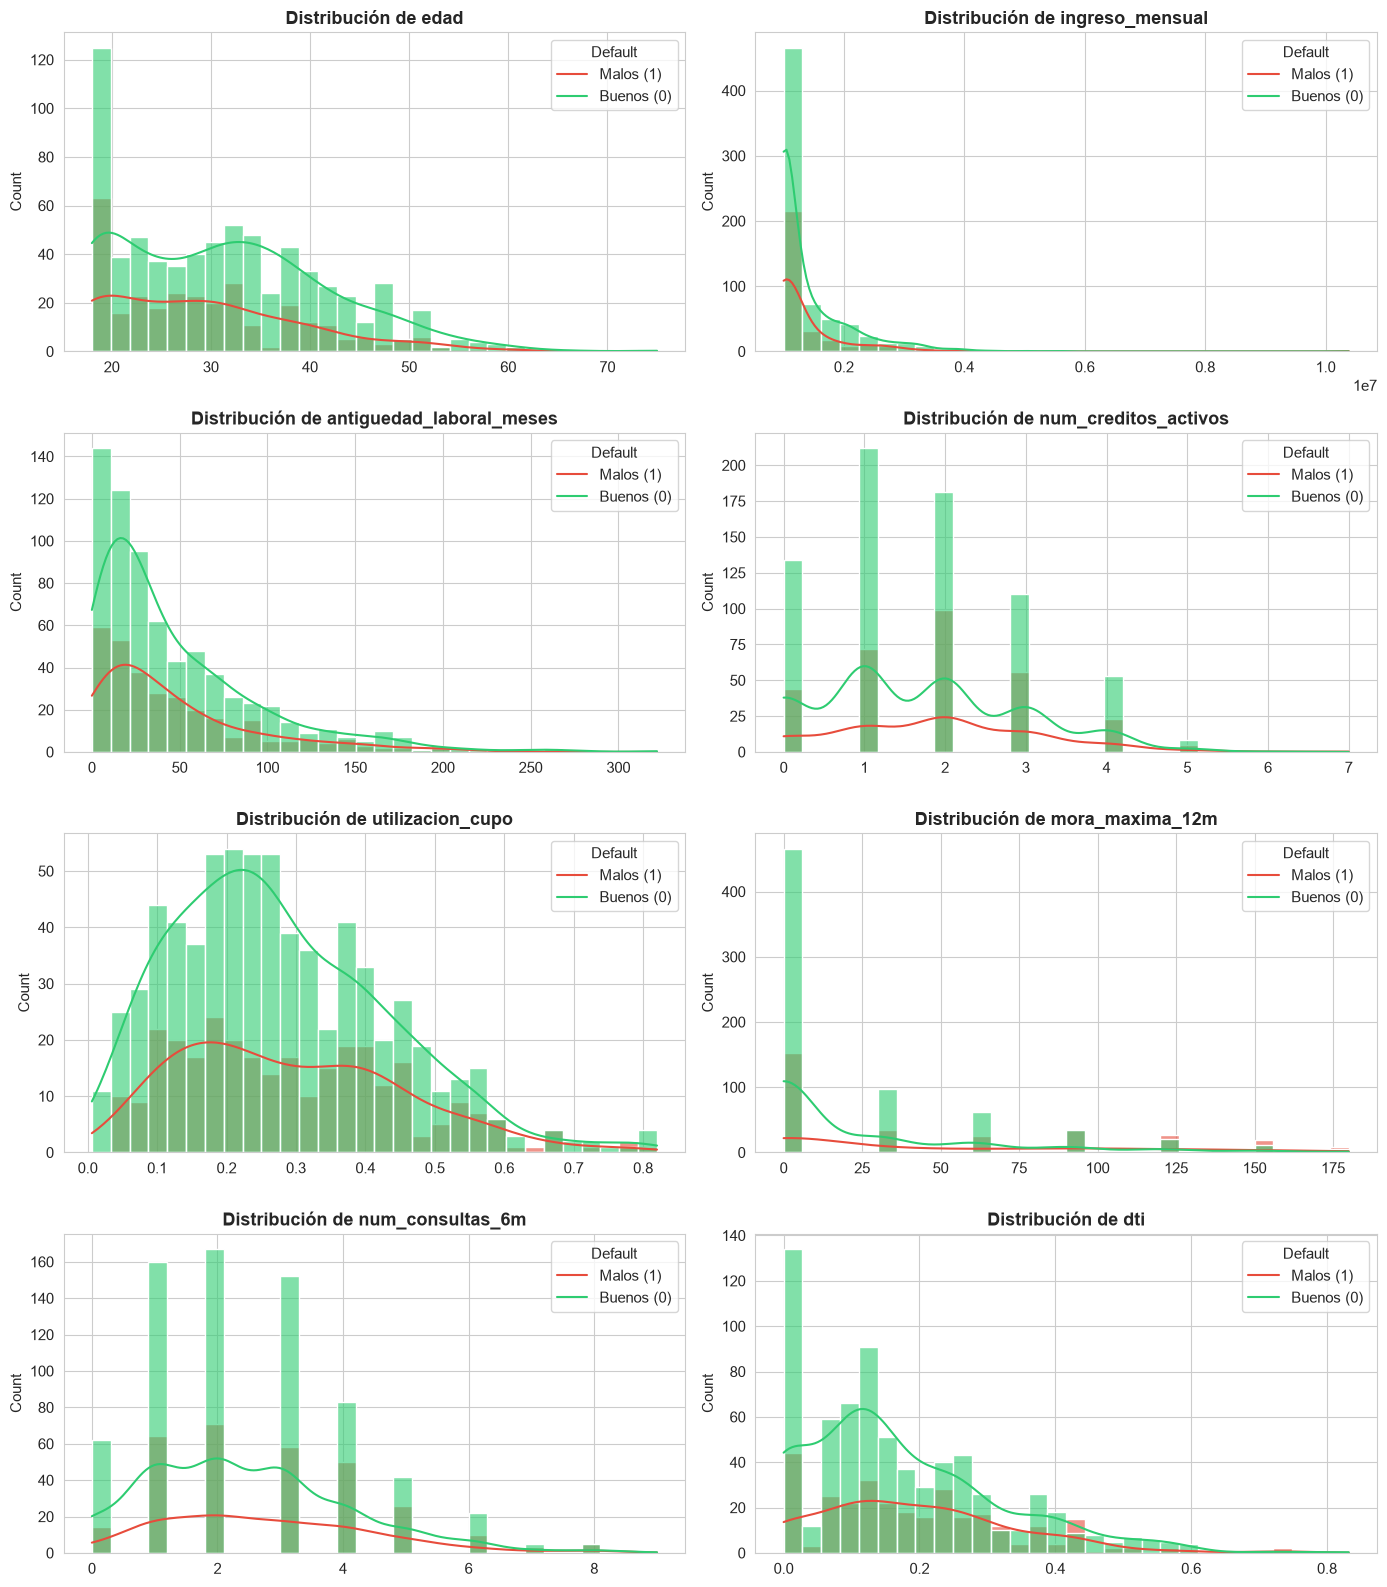

In [28]:
#===========================================================
# 6. Distribución de variables numéricas
#===========================================================

numeric_cols = ['edad', 'ingreso_mensual', 'antiguedad_laboral_meses',
                'num_creditos_activos', 'utilizacion_cupo', 'mora_maxima_12m',
                'num_consultas_6m', 'dti']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='default', kde=True,
                 ax=axes[i], palette=[  '#2ecc71', '#e74c3c'],
                 alpha=0.6, bins=30)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Default', labels=['Malos (1)', 'Buenos (0)'])

plt.tight_layout()
plt.savefig(r'D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\02_distribucion_numericas.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\JF_PalenciaGallo\AppData\Local\Temp\ipykernel_22052\2105118177.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_default, x='ciudad', y='mean', ax=axes[0], palette='Reds_r')
C:\Users\JF_PalenciaGallo\AppData\Local\Temp\ipykernel_22052\2105118177.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estrato_default, x='estrato', y='mean', ax=axes[1], palette='Reds_r')


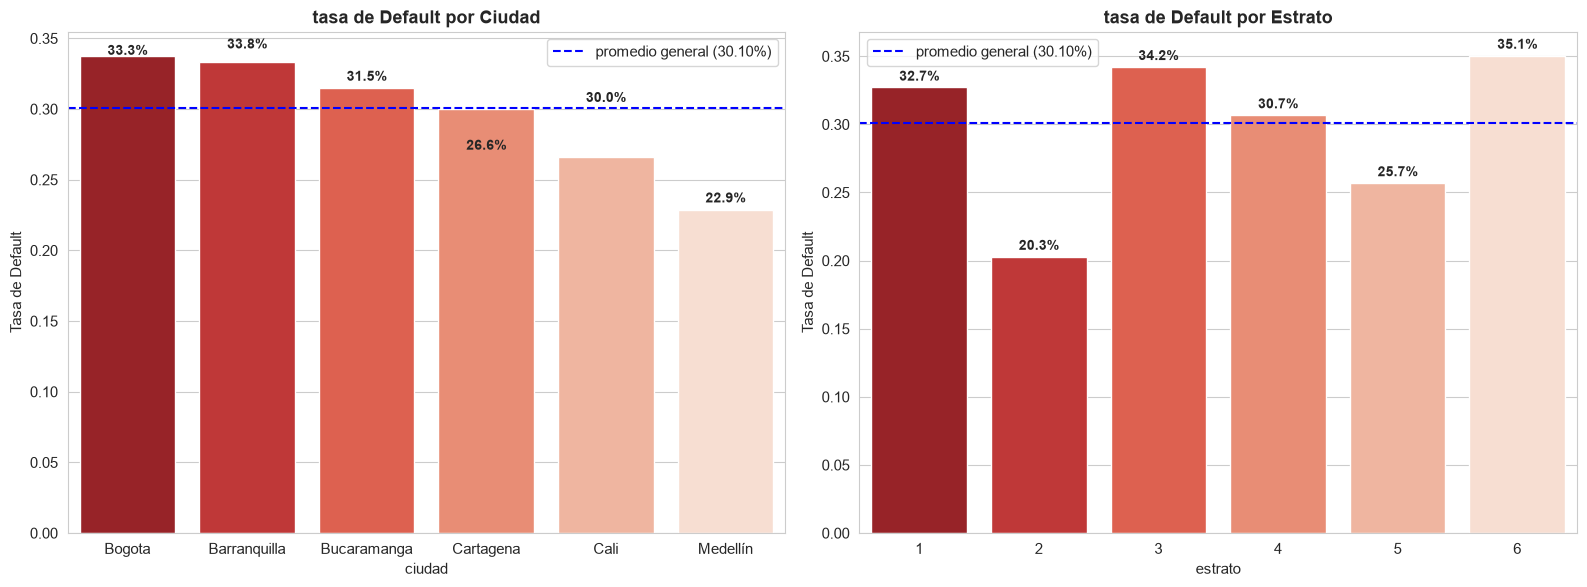


📊 Tasa de default por ciudad:


,ciudad,mean,count
1,Bogota,0.34,296
0,Barranquilla,0.33,114
2,Bucaramanga,0.32,200
4,Cartagena,0.30,70
3,Cali,0.27,154
5,Medellín,0.23,166



📊 Tasa de default por estrato:


,estrato,mean,count
0,1,0.33,107
1,2,0.20,138
2,3,0.34,263
3,4,0.31,251
4,5,0.26,144
5,6,0.35,97


In [29]:
#===============================================
# 7. Análisis de variables categoricas
#===============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ciudad vs Default
city_default = df.groupby('ciudad')['default'].agg(['mean', 'count']).reset_index()
city_default = city_default.sort_values(by='mean', ascending=False)

sns.barplot(data=city_default, x='ciudad', y='mean', ax=axes[0], palette='Reds_r')
axes[0].set_title('tasa de Default por Ciudad', fontweight='bold')
axes[0].set_ylabel('Tasa de Default')
axes[0].axhline(df['default'].mean(), color='blue', linestyle='--',
                label=f'promedio general ({df["default"].mean():.2%})')
axes[0].legend()

for i, row in city_default.iterrows():
    axes[0].text(i, row['mean'] + 0.005, f'{row["mean"]:.1%}',
                 ha='center', fontweight='bold', fontsize=10)


# Estrato vs default
estrato_default = df.groupby('estrato')['default'].agg(['mean', 'count']).reset_index()

sns.barplot(data=estrato_default, x='estrato', y='mean', ax=axes[1], palette='Reds_r')
axes[1].set_title('tasa de Default por Estrato', fontweight='bold')
axes[1].set_ylabel('Tasa de Default')
axes[1].axhline(df['default'].mean(), color='blue', linestyle='--',
                label=f'promedio general ({df["default"].mean():.2%})')
axes[1].legend()

for i, row in estrato_default.iterrows():
    axes[1].text(i, row['mean'] + 0.005, f'{row["mean"]:.1%}',
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(r'D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\03_categoricas_vs_target.png', dpi=100, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\n📊 Tasa de default por ciudad:")
display(city_default)

print("\n📊 Tasa de default por estrato:")
display(estrato_default)


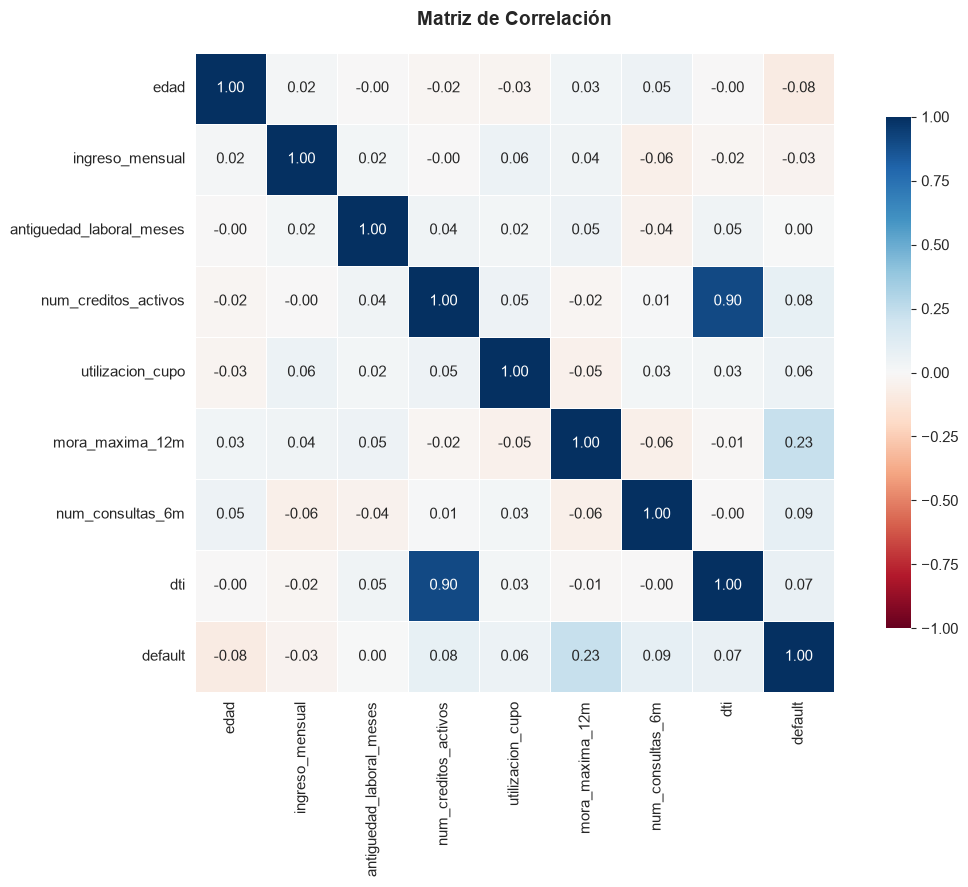


📊 Correlación con 'default' (ordenado por valor):
mora_maxima_12m             0.23
num_consultas_6m            0.09
num_creditos_activos        0.08
edad                       -0.08
dti                         0.07
utilizacion_cupo            0.06
ingreso_mensual            -0.03
antiguedad_laboral_meses    0.00
Name: default, dtype: float64


In [30]:
#===============================================
# 8. Matriz de correlación
#===============================================

plt.figure(figsize=(12, 9))

# Correlación de Pearson (para variables numéricas)
corr_matrix = df[numeric_cols + ['default']].corr()

# Heatmap de correlación
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Matriz de Correlación', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r'D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\02_Matriz_Correlacion.png', dpi=100, bbox_inches='tight')
plt.show()

# Top correlaciones con el target 'default'
print("\n📊 Correlación con 'default' (ordenado por valor):")
corr_target = corr_matrix['default'].drop('default').sort_values(key=abs,ascending=False)
print(corr_target)
